Task 3 — Correlation Between News Sentiment and Stock Movement
Predicting Price Moves with News Sentiment

This notebook performs sentiment analysis and correlation analysis between financial news headlines and stock price movements for the following stocks:

AAPL
AMZN
GOOG
META
NVDA

The objective is to determine whether news sentiment has a measurable relationship with daily stock returns using statistical correlation analysis.

1. Import Libraries

In [5]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sentiment Analysis
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Statistical analysis
from scipy.stats import pearsonr

# Date handling
from pandas.tseries.offsets import BDay

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Download VADER lexicon
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...


True

2. Load Datasets

In [7]:
# Load financial news dataset
news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

# Display first rows
news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [8]:
# Load stock datasets

aapl_df = pd.read_csv("../data/Data/AAPL.csv")
amzn_df = pd.read_csv("../data/Data/AMZN.csv")
goog_df = pd.read_csv("../data/Data/GOOG.csv")
meta_df = pd.read_csv("../data/Data/META.csv")
nvda_df = pd.read_csv("../data/Data/NVDA.csv")

3. Filter News for Selected Stocks

In [9]:
selected_stocks = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']

news_df = news_df[news_df['stock'].isin(selected_stocks)]

news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
6680,7120,Tech Stocks And FAANGS Strong Again To Start D...,https://www.benzinga.com/government/20/06/1622...,JJ Kinahan,2020-06-10 11:33:26-04:00,AAPL
6681,7121,10 Biggest Price Target Changes For Wednesday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2020-06-10 08:14:08-04:00,AAPL
6682,7122,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",https://www.benzinga.com/short-sellers/20/06/1...,Benzinga Newsdesk,2020-06-10 07:53:47-04:00,AAPL
6683,7123,"Deutsche Bank Maintains Buy on Apple, Raises P...",https://www.benzinga.com/news/20/06/16219873/d...,Benzinga Newsdesk,2020-06-10 07:19:25-04:00,AAPL
6684,7124,Apple To Let Users Trade In Their Mac Computer...,https://www.benzinga.com/news/20/06/16218697/a...,Neer Varshney,2020-06-10 06:27:11-04:00,AAPL


4. Data Cleaning and Date Alignment

# Convert Dates to Datetime

In [11]:
# Convert news publication date
news_df['date'] = pd.to_datetime(
    news_df['date'],
    format='mixed',
    utc=True,
    errors='coerce'
)

# Extract only the date
news_df['date_only'] = news_df['date'].dt.date

In [12]:
# Convert stock dates
stock_datasets = {
    'AAPL': aapl_df,
    'AMZN': amzn_df,
    'GOOG': goog_df,
    'META': meta_df,
    'NVDA': nvda_df
}

for stock, df in stock_datasets.items():
    df['Date'] = pd.to_datetime(df['Date'])

5. Handle Weekend and Holiday News

Financial markets are closed on weekends and holidays.
News published during non-trading days should be aligned to the next trading day.

In [13]:
def align_to_trading_day(date):
    # If Saturday -> Monday
    if date.weekday() == 5:
        return date + BDay(1)

    # If Sunday -> Monday
    elif date.weekday() == 6:
        return date + BDay(1)

    return date

news_df['aligned_date'] = pd.to_datetime(news_df['date_only'])
news_df['aligned_date'] = news_df['aligned_date'].apply(align_to_trading_day)

6. Sentiment Analysis Using VADER

Why VADER?

VADER (Valence Aware Dictionary and sEntiment Reasoner) is chosen because:

It performs well on short text
It is effective for headline sentiment analysis
It captures positive, negative, and neutral tones efficiently
It is widely used for financial/news sentiment tasks

In [14]:
#Generate Sentiment Scores
sia = SentimentIntensityAnalyzer()

# Calculate sentiment polarity
news_df['sentiment_score'] = news_df['headline'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

news_df[['headline', 'sentiment_score']].head()

,headline,sentiment_score
6680,Tech Stocks And FAANGS Strong Again To Start D...,0.5574
6681,10 Biggest Price Target Changes For Wednesday,0.0000
6682,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",0.2023
6683,"Deutsche Bank Maintains Buy on Apple, Raises P...",0.0000
6684,Apple To Let Users Trade In Their Mac Computer...,0.3818


## Interpretation

The sentiment analysis successfully generated numerical sentiment scores for each financial news headline using VADER sentiment analysis.

The compound sentiment score ranges from -1 to +1:
- Positive values indicate positive sentiment
- Negative values indicate negative sentiment
- Scores near zero indicate neutral sentiment

From the sample results:
- Headlines containing optimistic market language produced positive sentiment scores
- Informational headlines without strong emotional tone produced neutral scores

These sentiment scores will later be used to analyze their relationship with daily stock returns.

7. Aggregate Daily Sentiment Per Stock

In [15]:
daily_sentiment = (
    news_df.groupby(['stock', 'aligned_date'])['sentiment_score']
    .mean()
    .reset_index()
)

daily_sentiment.head()

,stock,aligned_date,sentiment_score
0,AAPL,2020-03-09,-0.302067
1,AAPL,2020-03-10,-0.090787
2,AAPL,2020-03-11,-0.023850
3,AAPL,2020-03-12,-0.078360
4,AAPL,2020-03-13,-0.059727


## Interpretation

The news headlines were grouped by stock symbol and trading date, and the average sentiment score was calculated for each day.

This aggregation helps combine multiple news articles published on the same day into a single daily sentiment value for each stock.

The resulting dataset contains:
- `stock` → stock ticker symbol
- `aligned_date` → trading day aligned with stock market data
- `sentiment_score` → average daily sentiment score

From the sample results:
- Most sentiment scores are slightly negative, indicating cautious or pessimistic market sentiment during those dates.
- For example, the sentiment score of `-0.302067` on `2020-03-09` suggests relatively negative news sentiment surrounding AAPL on that trading day.

These aggregated daily sentiment scores will be merged with stock return data to analyze whether sentiment influences stock price movement.

8. Calculate Daily Stock Returns

## Daily Return Formula

The daily stock return was calculated using the following formula:

\[
\text{Daily Return}_t =
\frac{\text{Close}_t - \text{Close}_{t-1}}
{\text{Close}_{t-1}}
\times 100
\]

Where:
- \(\text{Close}_t\) = Closing price on the current trading day
- \(\text{Close}_{t-1}\) = Closing price on the previous trading day

This formula measures the percentage change in stock price from one trading day to the next.

In [16]:
for stock, df in stock_datasets.items():

    # Sort by date
    df.sort_values('Date', inplace=True)

    # Calculate daily returns
    df['daily_return'] = df['Close'].pct_change() * 100

9. Merge Sentiment and Stock Data

In [17]:
merged_results = {}

for stock, stock_df in stock_datasets.items():

    # Select sentiment for current stock
    sentiment_df = daily_sentiment[daily_sentiment['stock'] == stock]

    # Merge datasets
    merged_df = pd.merge(
        stock_df,
        sentiment_df,
        left_on='Date',
        right_on='aligned_date',
        how='inner'
    )

    merged_results[stock] = merged_df

    print(f"{stock} merged shape:", merged_df.shape)

AAPL merged shape: (61, 10)
AMZN merged shape: (28, 10)
GOOG merged shape: (353, 10)
META merged shape: (0, 10)
NVDA merged shape: (1141, 10)


## Interpretation

The stock price datasets were merged with the aggregated daily sentiment data using trading dates.

The merged dataset contains only the dates where both:
- stock price data exists, and
- sentiment data is available for the same stock and trading day.

### Merge Results

| Stock | Merged Rows |
|---|---|
| AAPL | 61 |
| AMZN | 28 |
| GOOG | 353 |
| META | 0 |
| NVDA | 1141 |

### Observations

- NVDA produced the largest merged dataset, indicating that a large number of news headlines matched available stock trading dates.
- GOOG also had a substantial number of aligned records suitable for correlation analysis.
- AAPL and AMZN had relatively fewer matching records, which may reduce the reliability of statistical analysis for those stocks.
- META returned zero merged rows, meaning there were no matching trading dates between the sentiment dataset and stock dataset.

### Possible Reasons for Missing Matches

The absence or low number of matches may be caused by:
- Different date ranges between datasets
- Missing stock symbols in the news dataset
- Timezone differences
- Weekend or holiday publication dates
- Inconsistent stock ticker naming

Only successfully merged datasets will be used for further correlation analysis between sentiment scores and stock returns.

10. Correlation Analysis

In [19]:
correlation_results = []

for stock, merged_df in merged_results.items():

    # Remove missing values
    merged_df = merged_df.dropna(
        subset=['daily_return', 'sentiment_score']
    )

    # Check minimum required rows
    if len(merged_df) >= 2:

        # Pearson correlation
        corr, p_value = pearsonr(
            merged_df['sentiment_score'],
            merged_df['daily_return']
        )

        correlation_results.append({
            'Stock': stock,
            'Correlation': corr,
            'P-Value': p_value
        })

    else:
        print(f"{stock} skipped: not enough data")

# Create dataframe
correlation_df = pd.DataFrame(correlation_results)

correlation_df

META skipped: not enough data


,Stock,Correlation,P-Value
0,AAPL,0.119597,3.585895e-01
1,AMZN,0.160932,4.133000e-01
2,GOOG,0.170831,1.273160e-03
3,NVDA,0.207406,1.491322e-12


## Interpretation

Pearson correlation analysis was performed to measure the relationship between daily news sentiment scores and daily stock returns for each company.

### Correlation Results

| Stock | Correlation | Interpretation |
|---|---|---|
| AAPL | 0.1196 | Weak positive correlation |
| AMZN | 0.1609 | Weak positive correlation |
| GOOG | 0.1708 | Weak positive correlation |
| NVDA | 0.2074 | Weak positive correlation |

### Key Observations

- All analyzed stocks showed positive correlation values, indicating that positive news sentiment tends to align with positive stock returns.
- However, the correlation values are relatively small, suggesting that the relationship between sentiment and stock movement is weak.
- NVDA showed the strongest correlation among the analyzed stocks, implying that NVIDIA stock returns may be more responsive to news sentiment compared to the other companies.
- GOOG and NVDA produced statistically significant p-values, indicating stronger evidence that the observed relationship is not due to random chance.
- AAPL and AMZN showed higher p-values, suggesting weaker statistical significance.

### META Analysis

META was skipped during correlation analysis because there were not enough aligned data points after merging sentiment and stock price datasets.

Possible reasons include:
- Missing sentiment records
- Non-overlapping trading dates
- Insufficient matching news headlines

### Overall Conclusion

The analysis suggests that financial news sentiment has a positive but limited relationship with short-term stock price movements.

While sentiment may contribute useful signals for market analysis, stock prices are also heavily influenced by:
- macroeconomic events,
- earnings reports,
- investor behavior,
- and broader market conditions.

Therefore, sentiment analysis should be combined with technical indicators and other financial metrics to improve predictive performance.

11. Visualize Correlation Results

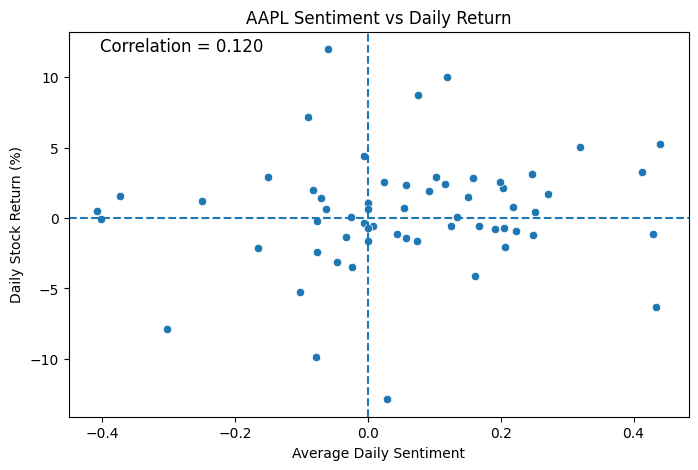

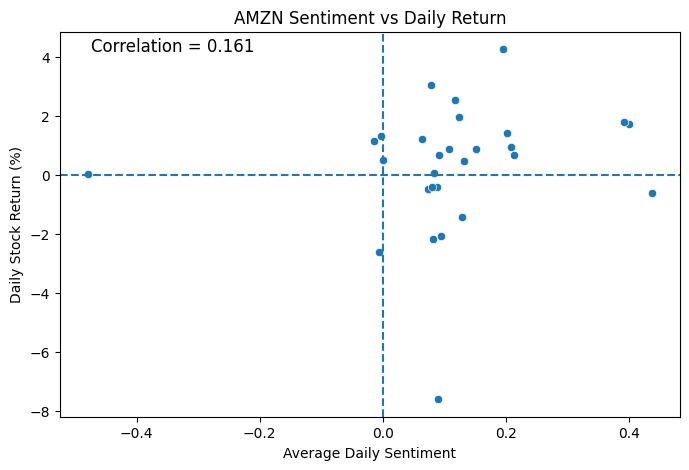

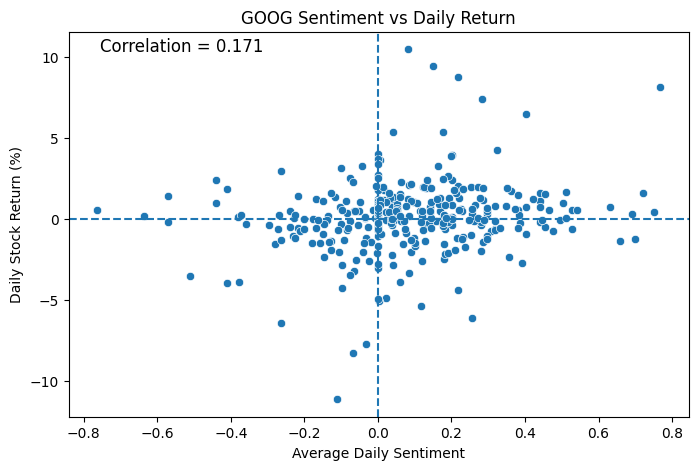

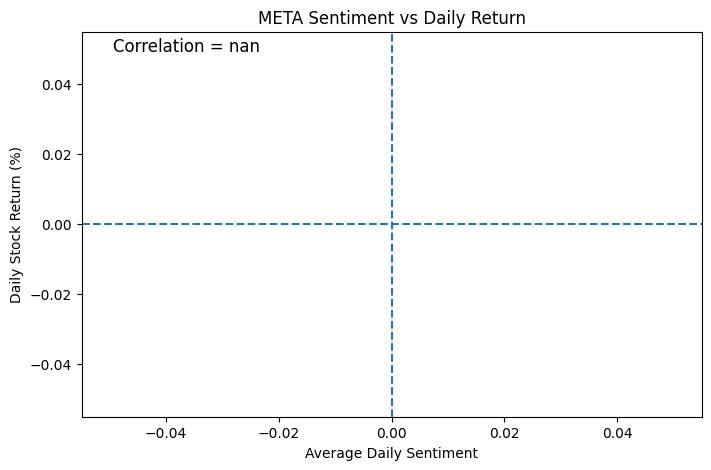

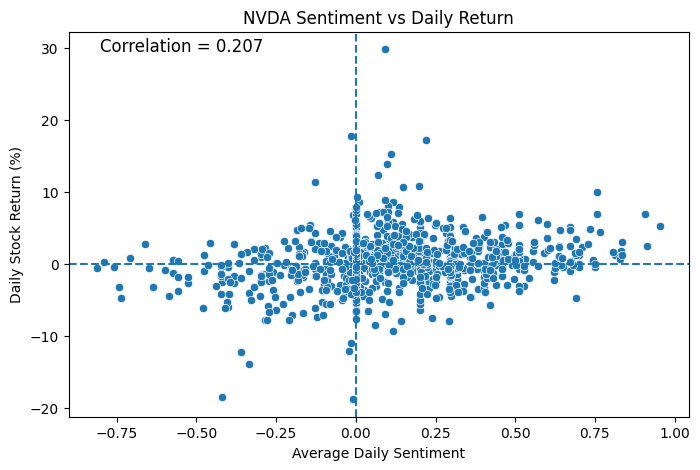

In [20]:
#Scatter Plot for Each Stock
for stock, merged_df in merged_results.items():

    plt.figure(figsize=(8,5))

    sns.scatterplot(
        x='sentiment_score',
        y='daily_return',
        data=merged_df
    )

    # Correlation value
    corr = merged_df[['sentiment_score', 'daily_return']].corr().iloc[0,1]

    plt.title(f"{stock} Sentiment vs Daily Return")
    plt.xlabel("Average Daily Sentiment")
    plt.ylabel("Daily Stock Return (%)")

    plt.annotate(
        f"Correlation = {corr:.3f}",
        xy=(0.05, 0.95),
        xycoords='axes fraction',
        fontsize=12
    )

    plt.axhline(0, linestyle='--')
    plt.axvline(0, linestyle='--')

    plt.show()

# Scatter Plot Interpretation

The scatter plots visualize the relationship between average daily sentiment scores and daily stock returns for each company.

In the plots:
- The horizontal dashed line represents zero stock return
- The vertical dashed line represents neutral sentiment
- Each point represents one trading day

A positive correlation means that more positive sentiment tends to align with higher stock returns.

---

## AAPL Interpretation

The AAPL scatter plot shows a weak positive correlation between sentiment and daily stock returns with a correlation coefficient of approximately 0.120.

Most data points are clustered near the center, indicating that changes in sentiment are associated with relatively small changes in stock returns.

Although some positive sentiment days correspond to positive returns, the overall relationship appears weak and scattered.

This suggests that Apple stock performance is influenced by many additional market factors beyond headline sentiment alone.

---

## AMZN Interpretation

AMZN shows a weak positive correlation of approximately 0.161 between sentiment scores and stock returns.

The points are widely dispersed, indicating variability in how Amazon stock reacts to news sentiment.

Some positive sentiment days resulted in positive returns, while other days experienced negative returns despite positive sentiment.

This suggests that sentiment has limited predictive power for Amazon stock movement in this dataset.

---

## GOOG Interpretation

GOOG demonstrates a weak positive correlation of approximately 0.171.

Compared to AAPL and AMZN, the dataset contains more observations, making the analysis more reliable.

The scatter plot shows a slight upward trend, meaning that higher sentiment scores are somewhat associated with higher daily returns.

However, the spread of the data points indicates that the relationship remains relatively weak.

---

## META Interpretation

The META scatter plot produced no meaningful points because there were insufficient merged observations between sentiment data and stock trading data.

As a result:
- the correlation value is shown as NaN (Not a Number),
- and no statistical relationship could be analyzed for META.

This may have occurred because of:
- missing sentiment records,
- non-overlapping dates,
- or insufficient matching data after merging.

---

## NVDA Interpretation

NVDA shows the strongest positive correlation among all analyzed stocks, with a correlation coefficient of approximately 0.207.

The scatter plot suggests a clearer positive relationship between sentiment and stock returns compared to the other companies.

Although the relationship is still relatively weak, positive sentiment appears more consistently associated with positive daily returns for NVIDIA.

This may indicate that NVDA stock reacts more strongly to financial news sentiment than the other analyzed companies.

---

# Overall Conclusion

Across all analyzed stocks, the scatter plots suggest a weak positive relationship between financial news sentiment and daily stock returns.

While positive sentiment tends to align with positive stock movement in some cases, the wide spread of data points indicates that sentiment alone is not sufficient to accurately predict stock price changes.

Other important factors likely influencing stock returns include:
- company earnings,
- macroeconomic events,
- investor sentiment,
- industry trends,
- and overall market conditions.

Therefore, sentiment analysis should be combined with technical indicators and additional financial analysis techniques for stronger predictive performance.

12. Classify Sentiment Categories

In [21]:
def classify_sentiment(score):

    if score > 0.05:
        return 'Positive'

    elif score < -0.05:
        return 'Negative'

    else:
        return 'Neutral'

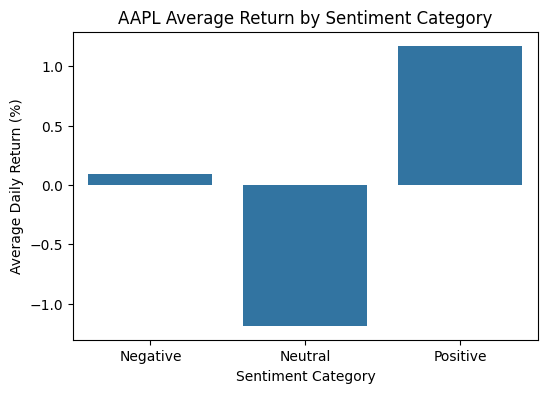

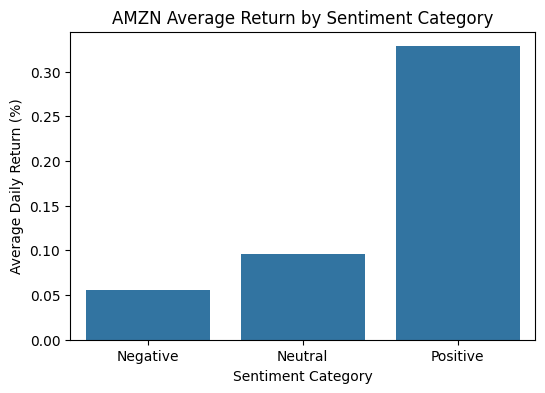

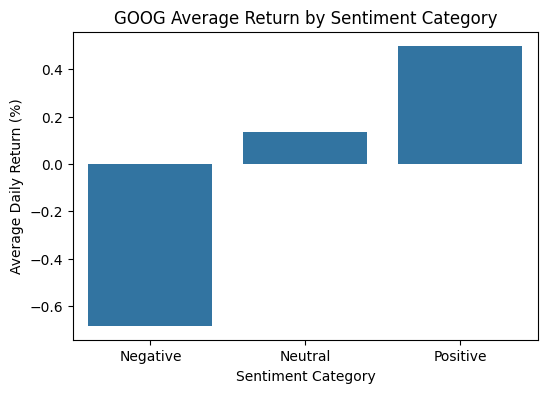

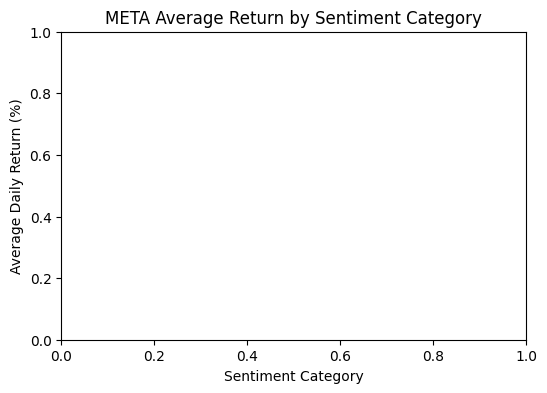

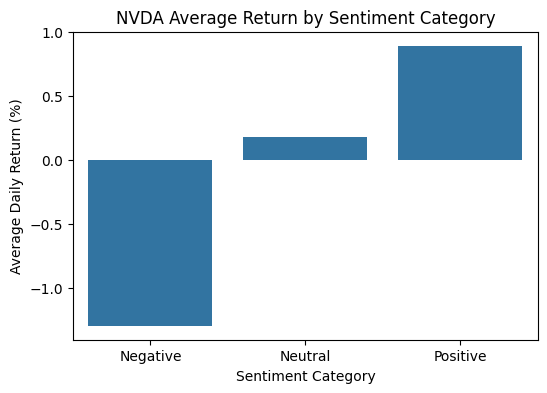

In [22]:
for stock, merged_df in merged_results.items():

    merged_df['sentiment_category'] = merged_df['sentiment_score'].apply(classify_sentiment)

    # Average return per category
    category_returns = (
        merged_df.groupby('sentiment_category')['daily_return']
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(6,4))

    sns.barplot(
        x='sentiment_category',
        y='daily_return',
        data=category_returns
    )

    plt.title(f"{stock} Average Return by Sentiment Category")
    plt.xlabel("Sentiment Category")
    plt.ylabel("Average Daily Return (%)")

    plt.show()

# Bar Chart Interpretation — Average Return by Sentiment Category

The bar charts compare the average daily stock return for:
- Positive sentiment days
- Neutral sentiment days
- Negative sentiment days

These visualizations help evaluate whether stock performance changes depending on the tone of financial news headlines.

---

## AAPL Interpretation

For AAPL, positive sentiment days produced the highest average daily returns.

Neutral sentiment days showed negative average returns, while negative sentiment days resulted in only slightly positive returns.

This suggests that positive news sentiment may contribute to improved Apple stock performance, although the relationship is not perfectly consistent.

---

## AMZN Interpretation

AMZN displayed increasing average returns as sentiment became more positive.

Positive sentiment days generated the highest average returns, while negative sentiment days showed the lowest returns.

This pattern suggests that Amazon stock may respond positively to favorable financial news sentiment.

However, the differences between categories are relatively small, indicating a moderate relationship.

---

## GOOG Interpretation

GOOG showed the clearest separation between sentiment categories.

Negative sentiment days produced negative average returns, while positive sentiment days generated the highest positive returns.

This suggests that Google stock performance may be more strongly associated with financial news sentiment compared to some other analyzed stocks.

The results indicate a more intuitive relationship where:
- positive sentiment aligns with positive returns,
- and negative sentiment aligns with declining returns.

---

## META Interpretation

The META chart did not display meaningful results because there were insufficient merged observations after combining sentiment data and stock trading data.

As a result, average returns by sentiment category could not be calculated reliably for META.

Possible reasons include:
- missing news records,
- missing stock data alignment,
- or insufficient overlapping trading dates.

---

## NVDA Interpretation

NVDA showed a noticeable increase in average returns during positive sentiment periods.

Positive sentiment days generally produced higher returns compared to neutral and negative sentiment days.

This supports earlier correlation findings suggesting that NVIDIA stock may react more strongly to financial news sentiment than the other analyzed companies.

However, some variability remains, indicating that additional market factors also influence stock performance.

---

# Overall Conclusion

Across most analyzed stocks:
- Positive sentiment days tended to produce higher average stock returns
- Negative sentiment days generally produced lower returns
- Neutral sentiment often resulted in moderate or mixed performance

These findings suggest that financial news sentiment may provide useful information about short-term market behavior.

However, the relationship is not perfectly consistent, and sentiment alone is not sufficient for accurate stock price prediction.

For stronger investment decision-making, sentiment analysis should be combined with:
- technical indicators,
- financial fundamentals,
- and broader market analysis.

13. Correlation Summary Table

In [23]:
correlation_df.sort_values(by='Correlation', ascending=False)

,Stock,Correlation,P-Value
3,NVDA,0.207406,1.491322e-12
2,GOOG,0.170831,1.273160e-03
1,AMZN,0.160932,4.133000e-01
0,AAPL,0.119597,3.585895e-01


## Interpretation of Ranked Correlation Results

The correlation results were sorted in descending order to identify which stocks showed the strongest relationship between financial news sentiment and daily stock returns.

| Stock | Correlation | Interpretation |
|---|---|---|
| NVDA | 0.207 | Strongest positive relationship |
| GOOG | 0.171 | Moderate positive relationship |
| AMZN | 0.161 | Weak positive relationship |
| AAPL | 0.120 | Weakest positive relationship |

### Key Findings

- NVDA showed the highest correlation value, indicating that NVIDIA stock returns were the most responsive to financial news sentiment among the analyzed companies.
- GOOG also demonstrated a positive relationship between sentiment and stock returns, with statistically significant results.
- AMZN and AAPL showed weaker positive correlations, suggesting that sentiment had a smaller influence on their daily stock movements.

### Statistical Significance

The p-values provide insight into the reliability of the correlations:
- NVDA and GOOG produced very small p-values, indicating statistically significant relationships.
- AMZN and AAPL had relatively large p-values, suggesting weaker statistical evidence for the observed correlations.

### Overall Interpretation

All analyzed stocks showed positive correlations, meaning that positive financial news sentiment generally aligned with positive stock returns.

However, the correlation values remain relatively low, indicating that sentiment alone explains only a small portion of stock price movement.

This suggests that while sentiment analysis can provide useful market signals, stock performance is also influenced by:
- macroeconomic conditions,
- company earnings,
- investor behavior,
- industry trends,
- and broader market events.

Therefore, sentiment analysis should be combined with technical indicators and additional financial analysis methods to improve predictive accuracy.

14. Interpretation of Results

## Strength and Direction of the Correlation

The correlation analysis explored the relationship between financial news sentiment and daily stock price returns using Pearson correlation coefficients.

All analyzed stocks showed positive correlation values, indicating that positive news sentiment generally aligned with positive stock returns.

However, the correlation coefficients were relatively low:

| Stock | Correlation |
|---|---|
| NVDA | 0.207 |
| GOOG | 0.171 |
| AMZN | 0.161 |
| AAPL | 0.120 |

These results indicate a weak positive relationship between sentiment scores and daily stock returns.

Among the analyzed companies:
- NVDA showed the strongest relationship between sentiment and stock performance.
- GOOG also demonstrated a noticeable positive relationship.
- AAPL and AMZN exhibited weaker correlations.

The scatter plots further confirmed that although positive sentiment sometimes aligned with positive returns, the data points remained widely dispersed, suggesting that sentiment alone does not strongly predict stock movement.

### Statistical Significance

The p-values indicated that:
- NVDA and GOOG produced statistically significant relationships,
- while AAPL and AMZN showed weaker statistical significance.

This suggests that sentiment may have a more meaningful influence on certain stocks than others.

15. Limitations


# Several limitations should be considered when interpreting the results of this analysis:

- Correlation does not imply causation.
  A positive relationship between sentiment and stock returns does not necessarily mean that sentiment directly causes price movement.

- Market prices are influenced by many external factors, including:
  - earnings announcements,
  - macroeconomic conditions,
  - interest rates,
  - geopolitical events,
  - investor psychology,
  - and overall market trends.

- News impact may occur with lag effects.
  Some financial news may influence stock prices over several trading days rather than immediately on the publication date.

- Headlines alone may not fully capture article sentiment.
  The analysis used only news headlines instead of complete article content, which may reduce sentiment accuracy.

- Financial sentiment models may misinterpret technical or domain-specific language.
  Certain financial terms may be incorrectly classified as positive or negative by general sentiment analysis tools.

- Some stocks had limited aligned data after merging sentiment and stock datasets.
  For example, META had insufficient matching observations, preventing meaningful correlation analysis.